In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv(
    "CareerCompass_AI_Student_Dataset.csv"
)

print(df.head())

print("\nDataset Shape")

print(df.shape)

   StudentID   StudentName Department  Year  CGPA  Backlogs
0       1001  Student_1001        EEE     2  7.56         0
1       1002  Student_1002        CSE     1  7.82         0
2       1003  Student_1003        CSE     2  7.57         0
3       1004  Student_1004        CSE     2  8.66         0
4       1005  Student_1005      Civil     3  8.01         0

Dataset Shape
(100, 6)


In [3]:
def backlog_category(x):

    if x == 0:
        return "0"

    elif x <= 5:
        return "1-5"

    elif x <= 10:
        return "6-10"

    elif x <= 15:
        return "11-15"

    elif x <= 20:
        return "16-20"

    else:
        return "20+"

df["BacklogCategory"] = df["Backlogs"].apply(
    backlog_category
)

In [4]:
def calculate_score(cgpa, backlogs):

    score = 100

    score -= max(0, (8-cgpa))*10

    score -= backlogs*2

    return max(0, round(score))

df["CareerReadinessScore"] = df.apply(

    lambda row:

    calculate_score(
        row["CGPA"],
        row["Backlogs"]
    ),

    axis=1
)

In [5]:
def risk_level(score):

    if score >= 80:
        return "Excellent"

    elif score >= 60:
        return "Good"

    elif score >= 40:
        return "Needs Improvement"

    else:
        return "High Risk"

df["RiskLevel"] = (

    df["CareerReadinessScore"]

    .apply(risk_level)

)

/tmp/ipykernel_945/2162948083.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


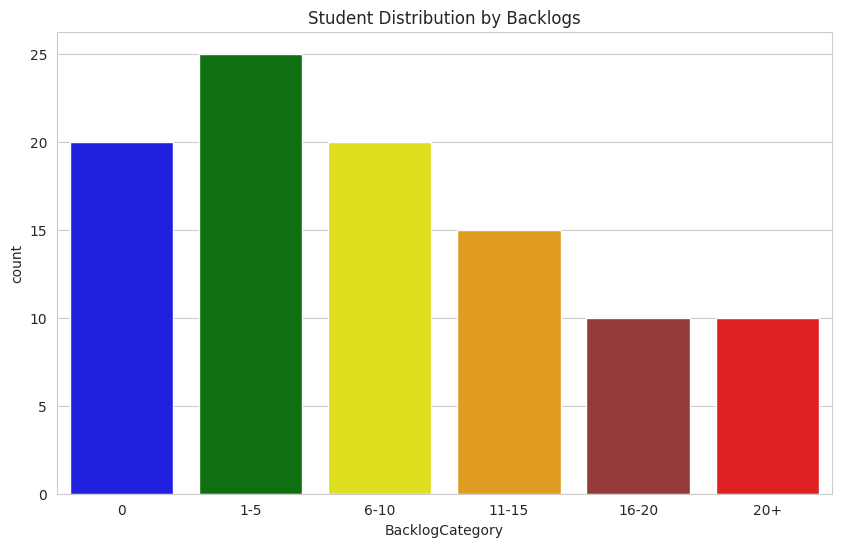

In [6]:
colors = {

    "0":"blue",

    "1-5":"green",

    "6-10":"yellow",

    "11-15":"orange",

    "16-20":"brown",

    "20+":"red"

}

plt.figure(figsize=(10,6))

sns.countplot(

    x="BacklogCategory",

    data=df,

    palette=colors

)

plt.title(
    "Student Distribution by Backlogs"
)

plt.show()

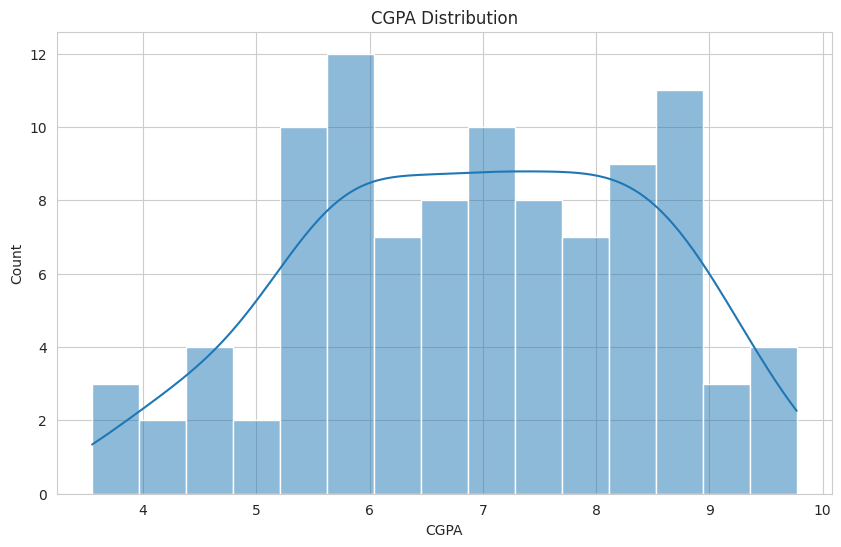

In [7]:
plt.figure(figsize=(10,6))

sns.histplot(

    df["CGPA"],

    bins=15,

    kde=True

)

plt.title(
    "CGPA Distribution"
)

plt.show()

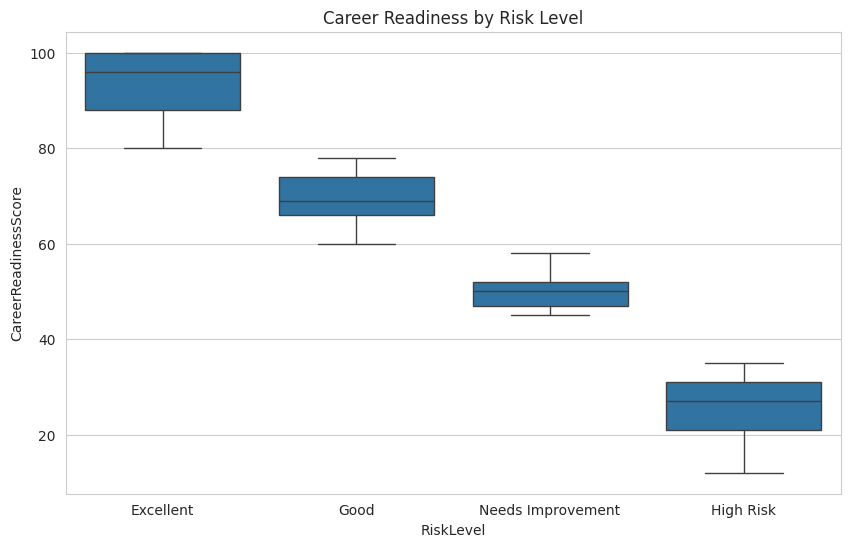

In [11]:
plt.figure(figsize=(10,6))

sns.boxplot(

    x="RiskLevel",

    y="CareerReadinessScore",

    data=df

)

plt.title(
    "Career Readiness by Risk Level"
)

plt.show()

In [13]:
department = input(
    "Enter Department: "
)

cgpa = float(
    input("Enter CGPA: ")
)

backlogs = int(
    input("Enter Number of Backlogs: ")
)

interest = input(
    "Enter Interest Area: "
)

Enter Department: CSE
Enter CGPA: 6.2
Enter Number of Backlogs: 5
Enter Interest Area: Data Science


In [14]:
student_score = calculate_score(
    cgpa,
    backlogs
)

student_risk = risk_level(
    student_score
)

print()

print("="*60)

print("CAREER REPORT")

print("="*60)

print()

print(
    "Career Readiness Score:",
    student_score
)

print(
    "Risk Level:",
    student_risk
)


CAREER REPORT

Career Readiness Score: 72
Risk Level: Good


In [15]:
paths = {

"CSE":[

"Software Development",

"Data Analytics",

"AI/ML",

"Cloud Computing",

"Cybersecurity"

],

"ECE":[

"Embedded Systems",

"VLSI",

"IoT",

"Data Analytics",

"Software Development"

],

"EEE":[

"Power Systems",

"Electrical Design",

"Automation",

"Energy Analytics"

],

"Mechanical":[

"Manufacturing",

"Quality Engineer",

"Design Engineer",

"Supply Chain Analytics",

"Data Analytics"

],

"Civil":[

"Site Engineer",

"Construction Analytics",

"Project Planning",

"GIS Analytics"

],

"Aerospace":[

"Aerospace Design",

"Simulation",

"Aircraft Maintenance",

"Data Analytics"

]

}

print()

print("Recommended Career Paths")

print("------------------------")

for p in paths.get(

    department,

    ["General Analytics"]

):

    print("•", p)


Recommended Career Paths
------------------------
• Software Development
• Data Analytics
• AI/ML
• Cloud Computing
• Cybersecurity


In [16]:
print()

print("="*60)

print("PERSONALIZED FEEDBACK")

print("="*60)

if backlogs >= 15:

    print(
        "Priority is backlog clearance."
    )

elif backlogs >= 5:

    print(
        "Balance backlog clearance with skill development."
    )

else:

    print(
        "Focus on projects and internships."
    )

if cgpa >= 8:

    print(
        "Strong academic profile."
    )

elif cgpa >= 6:

    print(
        "Average academic profile."
    )

else:

    print(
        "Improve academics and focus on fundamentals."
    )


PERSONALIZED FEEDBACK
Balance backlog clearance with skill development.
Average academic profile.


In [17]:
print()

print("="*60)

print("6-MONTH ACTION PLAN")

print("="*60)

if backlogs >= 10:

    print("""
Month 1:
Clear highest-priority backlog subjects

Month 2:
Continue backlog preparation

Month 3:
Learn Excel

Month 4:
Learn SQL

Month 5:
Build one project

Month 6:
Prepare resume and LinkedIn
""")

elif backlogs >= 5:

    print("""
Month 1:
Clear at least 2 backlogs

Month 2:
Learn Excel

Month 3:
Learn SQL

Month 4:
Learn Python

Month 5:
Build one project

Month 6:
Apply for internships
""")

else:

    print("""
Month 1:
Excel + SQL

Month 2:
Python

Month 3:
Data Analysis Project

Month 4:
Power BI

Month 5:
Portfolio Building

Month 6:
Internship Applications
""")


6-MONTH ACTION PLAN

Month 1:
Clear at least 2 backlogs

Month 2:
Learn Excel

Month 3:
Learn SQL

Month 4:
Learn Python

Month 5:
Build one project

Month 6:
Apply for internships



In [18]:
print()

print("="*60)

print("12-MONTH TARGET")

print("="*60)

if student_score >= 80:

    print(
        "Target internships, product companies, and advanced projects."
    )

elif student_score >= 60:

    print(
        "Target internships, strong portfolio, and placement preparation."
    )

else:

    print(
        "Focus on backlog recovery, skills, projects, then placements."
    )


12-MONTH TARGET
Target internships, strong portfolio, and placement preparation.


In [19]:
report = {

    "Department":[department],

    "CGPA":[cgpa],

    "Backlogs":[backlogs],

    "Interest":[interest],

    "CareerReadinessScore":[student_score],

    "RiskLevel":[student_risk]

}

report_df = pd.DataFrame(report)

report_df.to_csv(

    "CareerCompass_AI_Report.csv",

    index=False

)

print()

print(
    "Career Report Saved Successfully"
)


Career Report Saved Successfully
